In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, mean_absolute_error, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
import shap

print("✅ Step 1: Libraries imported successfully!")

✅ Step 1: Libraries imported successfully!


In [8]:
# Load Dataset
df = pd.read_csv(r"D:\ML_learning\NYC+Accidents+2020.csv\NYC Accidents 2020.csv")

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print("\n--- Column List ---")
print(df.columns.tolist())

print("\n--- Missing Values Count ---")
print(df.isnull().sum())

df.head()

Dataset Shape: 74881 rows, 29 columns

--- Column List ---
['CRASH DATE', 'CRASH TIME', 'BOROUGH', 'ZIP CODE', 'LATITUDE', 'LONGITUDE', 'LOCATION', 'ON STREET NAME', 'CROSS STREET NAME', 'OFF STREET NAME', 'NUMBER OF PERSONS INJURED', 'NUMBER OF PERSONS KILLED', 'NUMBER OF PEDESTRIANS INJURED', 'NUMBER OF PEDESTRIANS KILLED', 'NUMBER OF CYCLIST INJURED', 'NUMBER OF CYCLIST KILLED', 'NUMBER OF MOTORIST INJURED', 'NUMBER OF MOTORIST KILLED', 'CONTRIBUTING FACTOR VEHICLE 1', 'CONTRIBUTING FACTOR VEHICLE 2', 'CONTRIBUTING FACTOR VEHICLE 3', 'CONTRIBUTING FACTOR VEHICLE 4', 'CONTRIBUTING FACTOR VEHICLE 5', 'COLLISION_ID', 'VEHICLE TYPE CODE 1', 'VEHICLE TYPE CODE 2', 'VEHICLE TYPE CODE 3', 'VEHICLE TYPE CODE 4', 'VEHICLE TYPE CODE 5']

--- Missing Values Count ---
CRASH DATE                           0
CRASH TIME                           0
BOROUGH                          25738
ZIP CODE                         25747
LATITUDE                          5946
LONGITUDE                         5

,CRASH DATE,CRASH TIME,BOROUGH,ZIP CODE,LATITUDE,LONGITUDE,LOCATION,ON STREET NAME,CROSS STREET NAME,OFF STREET NAME,...,CONTRIBUTING FACTOR VEHICLE 2,CONTRIBUTING FACTOR VEHICLE 3,CONTRIBUTING FACTOR VEHICLE 4,CONTRIBUTING FACTOR VEHICLE 5,COLLISION_ID,VEHICLE TYPE CODE 1,VEHICLE TYPE CODE 2,VEHICLE TYPE CODE 3,VEHICLE TYPE CODE 4,VEHICLE TYPE CODE 5
0,8/29/2020,15:40:00,BRONX,10466.0,40.89210,-73.833760,POINT (-73.83376 40.8921),PRATT AVENUE,STRANG AVENUE,NaN,...,Unspecified,NaN,NaN,NaN,4342908,Sedan,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN
1,8/29/2020,21:00:00,BROOKLYN,11221.0,40.69050,-73.919914,POINT (-73.919914 40.6905),BUSHWICK AVENUE,PALMETTO STREET,NaN,...,Unspecified,NaN,NaN,NaN,4343555,Sedan,Sedan,NaN,NaN,NaN
2,8/29/2020,18:20:00,not available,NaN,40.81650,-73.946556,POINT (-73.946556 40.8165),8 AVENUE,not available,NaN,...,NaN,NaN,NaN,NaN,4343142,Station Wagon/Sport Utility Vehicle,NaN,NaN,NaN,NaN
3,8/29/2020,0:00:00,BRONX,10459.0,40.82472,-73.892960,POINT (-73.89296 40.82472),NaN,NaN,1047 SIMPSON STREET,...,Unspecified,Unspecified,Unspecified,NaN,4343588,Station Wagon/Sport Utility Vehicle,Station Wagon/Sport Utility Vehicle,Sedan,Motorcycle,NaN
4,8/29/2020,17:10:00,BROOKLYN,11203.0,40.64989,-73.933890,POINT (-73.93389 40.64989),NaN,NaN,4609 SNYDER AVENUE,...,Unspecified,NaN,NaN,NaN,4342953,Sedan,Sedan,NaN,NaN,NaN


In [9]:
# Target definition: 0 = Property Damage Only, 1 = Injury, 2 = Fatal
def assign_severity(row):
    if row['NUMBER OF PERSONS KILLED'] > 0:
        return 2  # Fatal
    elif row['NUMBER OF PERSONS INJURED'] > 0:
        return 1  # Injury
    else:
        return 0  # Property Damage Only

df['SEVERITY'] = df.apply(assign_severity, axis=1)

print("Target variable created successfully!")
print(df['SEVERITY'].value_counts())

Target variable created successfully!
SEVERITY
0    54371
1    20375
2      135
Name: count, dtype: int64


In [10]:
# 1. Fill missing text categories with 'Unspecified'
categorical_cols = ['BOROUGH', 'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1']
for col in categorical_cols:
    df[col] = df[col].fillna('Unspecified')

# 2. Fill missing spatial coordinates using Median
df['LATITUDE'] = df['LATITUDE'].fillna(df['LATITUDE'].median())
df['LONGITUDE'] = df['LONGITUDE'].fillna(df['LONGITUDE'].median())

print("Data cleaning & imputation completed!")

Data cleaning & imputation completed!


In [12]:
# Extract datetime components
df['CRASH DATE'] = pd.to_datetime(df['CRASH DATE'])
df['CRASH_MONTH'] = df['CRASH DATE'].dt.month
df['DAY_OF_WEEK'] = df['CRASH DATE'].dt.dayofweek
df['IS_WEEKEND'] = df['DAY_OF_WEEK'].apply(lambda x: 1 if x >= 5 else 0)

# Extract crash hour
crash_datetime = pd.to_datetime(df['CRASH DATE'].astype(str) + ' ' + df['CRASH TIME'].astype(str), errors='coerce')
df['CRASH_HOUR'] = crash_datetime.dt.hour
df['CRASH_HOUR'] = df['CRASH_HOUR'].fillna(df['CRASH_HOUR'].median())

print("Feature engineering completed!")

Feature engineering completed!


C:\Users\PL\AppData\Local\Temp\ipykernel_936\2642561858.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SEVERITY', data=df, palette='viridis')
C:\Users\PL\AppData\Local\Temp\ipykernel_936\2642561858.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='CRASH_MONTH', data=df, palette='Purples_r')


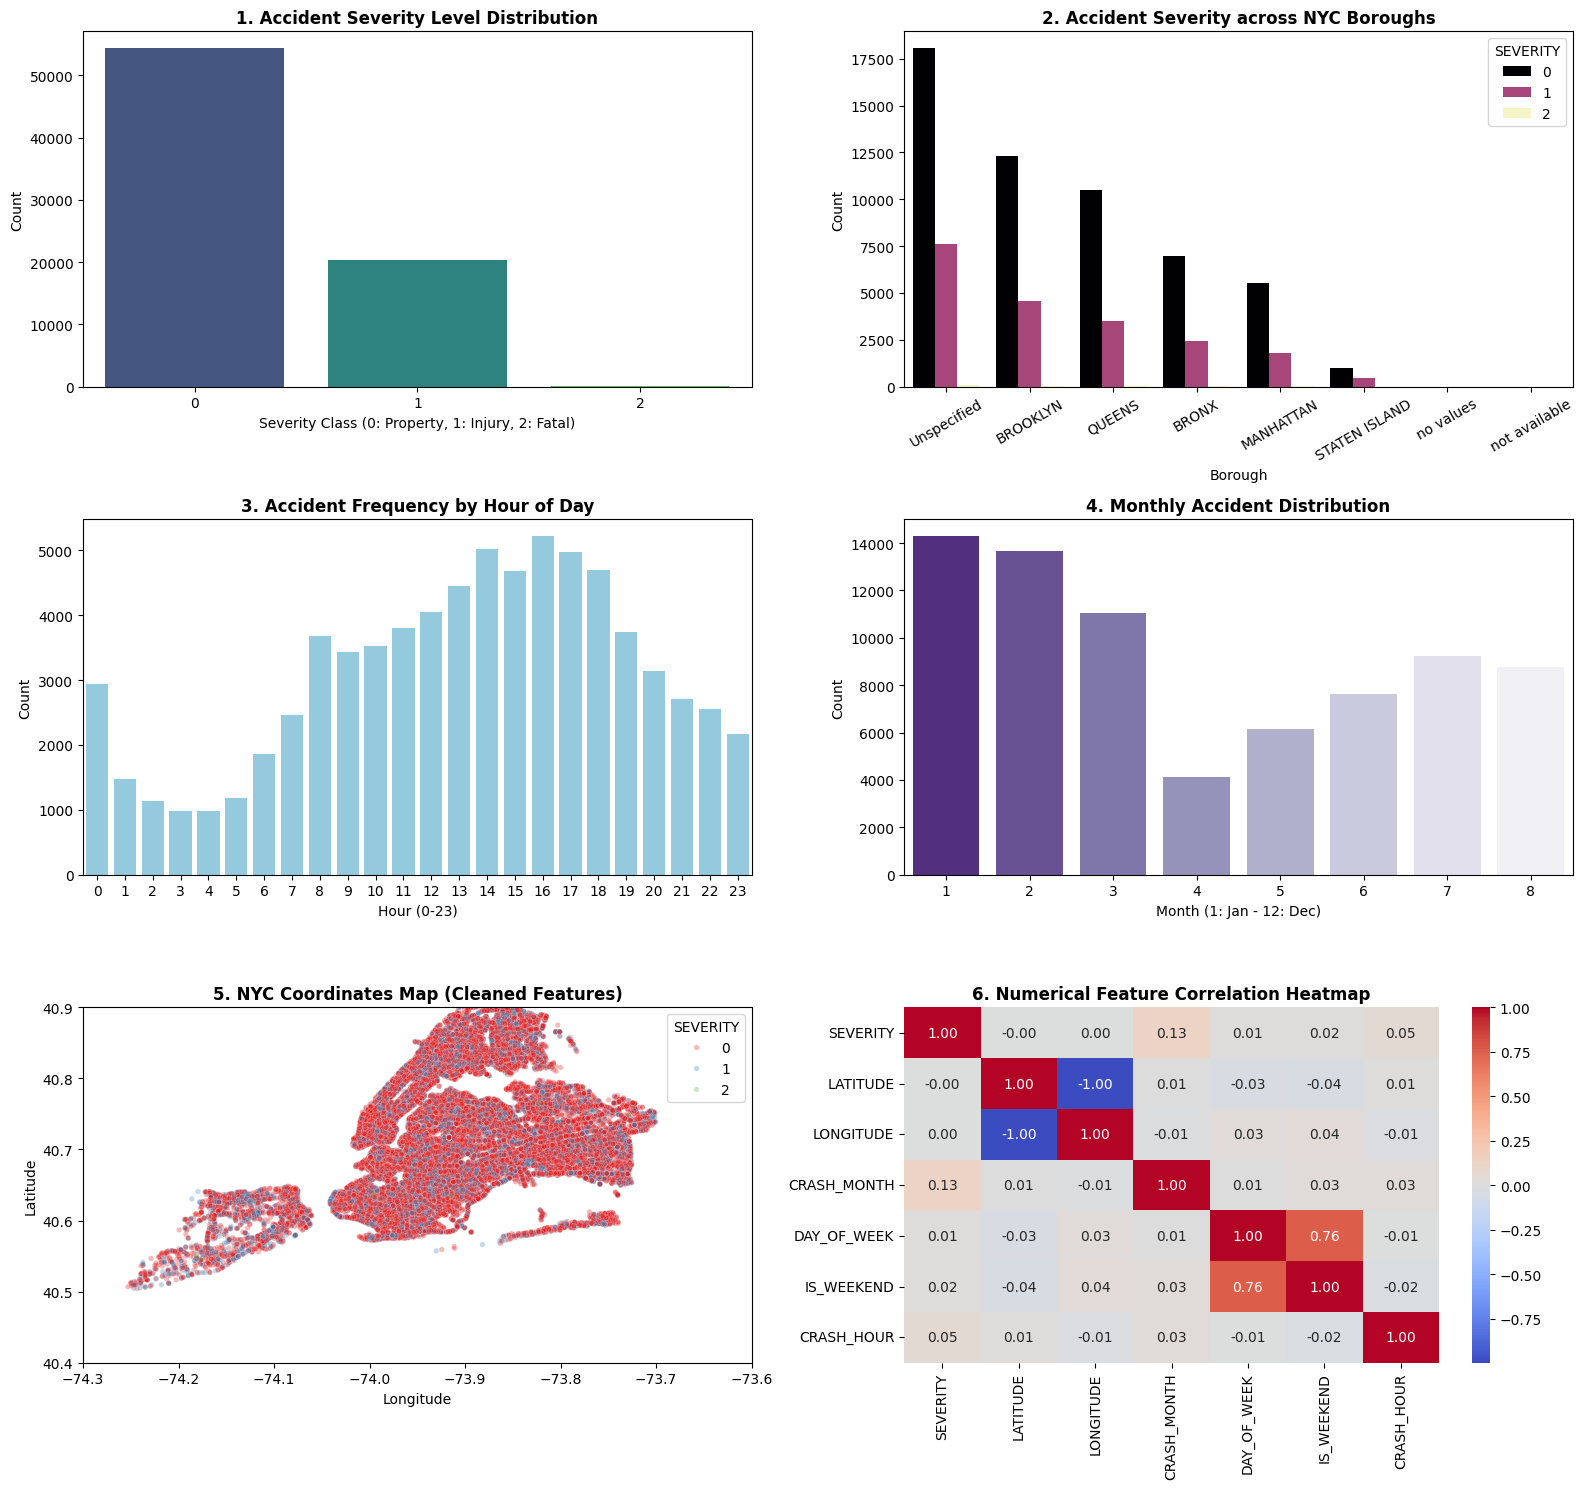

In [13]:
plt.figure(figsize=(16, 15))

# Plot 1: Target Severity Distribution
plt.subplot(3, 2, 1)
sns.countplot(x='SEVERITY', data=df, palette='viridis')
plt.title('1. Accident Severity Level Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Severity Class (0: Property, 1: Injury, 2: Fatal)')
plt.ylabel('Count')

# Plot 2: Accidents by Borough grouped by Severity
plt.subplot(3, 2, 2)
sns.countplot(x='BOROUGH', hue='SEVERITY', data=df, palette='magma', order=df['BOROUGH'].value_counts().index)
plt.title('2. Accident Severity across NYC Boroughs', fontsize=12, fontweight='bold')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.xticks(rotation=30)

# Plot 3: Hourly Accident Trends
plt.subplot(3, 2, 3)
sns.countplot(x='CRASH_HOUR', data=df, color='skyblue')
plt.title('3. Accident Frequency by Hour of Day', fontsize=12, fontweight='bold')
plt.xlabel('Hour (0-23)')
plt.ylabel('Count')

# Plot 4: Monthly Trend of Crashes
plt.subplot(3, 2, 4)
sns.countplot(x='CRASH_MONTH', data=df, palette='Purples_r')
plt.title('4. Monthly Accident Distribution', fontsize=12, fontweight='bold')
plt.xlabel('Month (1: Jan - 12: Dec)')
plt.ylabel('Count')

# Plot 5: Spatial Geographic Map (Latitude vs Longitude)
plt.subplot(3, 2, 5)
sns.scatterplot(x='LONGITUDE', y='LATITUDE', hue='SEVERITY', data=df, alpha=0.3, palette='Set1', s=15)
plt.title('5. NYC Coordinates Map (Cleaned Features)', fontsize=12, fontweight='bold')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.xlim(-74.3, -73.6)
plt.ylim(40.4, 40.9)

# Plot 6: Feature Correlation Heatmap (Fixed: using df directly)
plt.subplot(3, 2, 6)
numeric_features = ['SEVERITY', 'LATITUDE', 'LONGITUDE', 'CRASH_MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'CRASH_HOUR']
sns.heatmap(df[numeric_features].corr(), cmap='coolwarm', annot=True, fmt='.2f', cbar=True)
plt.title('6. Numerical Feature Correlation Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('nyc_accident_eda_6plots.png', dpi=300)
plt.show()

In [14]:
selected_features = [
    'BOROUGH', 'LATITUDE', 'LONGITUDE', 
    'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1',
    'CRASH_MONTH', 'DAY_OF_WEEK', 'IS_WEEKEND', 'CRASH_HOUR'
]

X = df[selected_features].copy()
y = df['SEVERITY']

# Encoding categorical strings to numerical IDs
encoders = {}
for col in ['BOROUGH', 'CONTRIBUTING FACTOR VEHICLE 1', 'VEHICLE TYPE CODE 1']:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    encoders[col] = le

X.head()

,BOROUGH,LATITUDE,LONGITUDE,CONTRIBUTING FACTOR VEHICLE 1,VEHICLE TYPE CODE 1,CRASH_MONTH,DAY_OF_WEEK,IS_WEEKEND,CRASH_HOUR
0,0,40.89210,-73.833760,31,179,8,5,1,15
1,1,40.69050,-73.919914,38,179,8,5,1,21
2,7,40.81650,-73.946556,4,182,8,5,1,18
3,0,40.82472,-73.892960,49,182,8,5,1,0
4,1,40.64989,-73.933890,14,179,8,5,1,17


In [15]:
# 1. Split data (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# 2. Standardize Features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X.columns)

# 3. Handle Imbalance with SMOTE
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("Data scaled and balanced with SMOTE successfully!")

Data scaled and balanced with SMOTE successfully!


In [16]:
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=6,
    min_samples_split=10,
    random_state=42
)

print("Training Decision Tree Classifier...")
dt_model.fit(X_train_res, y_train_res)
print("Training Completed!")

Training Decision Tree Classifier...
Training Completed!


In [17]:
# Predict test set
y_pred_dt = dt_model.predict(X_test_scaled)

# Calculate Evaluation Metrics
acc = accuracy_score(y_test, y_pred_dt) * 100
prec = precision_score(y_test, y_pred_dt, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred_dt, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred_dt, average='weighted', zero_division=0)
mae = mean_absolute_error(y_test, y_pred_dt)

# Format into standard comparison table
results_df = pd.DataFrame({
    'Algorithm': ['Decision Tree'],
    'Accuracy (%)': [f"{acc:.2f}"],
    'Precision': [f"{prec:.4f}"],
    'Recall': [f"{rec:.4f}"],
    'F1-Score': [f"{f1:.4f}"],
    'MAE': [f"{mae:.4f}"]
})

print("=== Model Performance Summary ===")
print(results_df.to_string(index=False))

print("\n=== Detailed Classification Report ===")
print(classification_report(y_test, y_pred_dt, target_names=['Property Damage', 'Injury', 'Fatal']))

=== Model Performance Summary ===
    Algorithm Accuracy (%) Precision Recall F1-Score    MAE
Decision Tree        67.13    0.6499 0.6713   0.6388 0.3674

=== Detailed Classification Report ===
                 precision    recall  f1-score   support

Property Damage       0.74      0.87      0.80     10875
         Injury       0.40      0.14      0.20      4075
          Fatal       0.00      0.04      0.00        27

       accuracy                           0.67     14977
      macro avg       0.38      0.35      0.34     14977
   weighted avg       0.65      0.67      0.64     14977



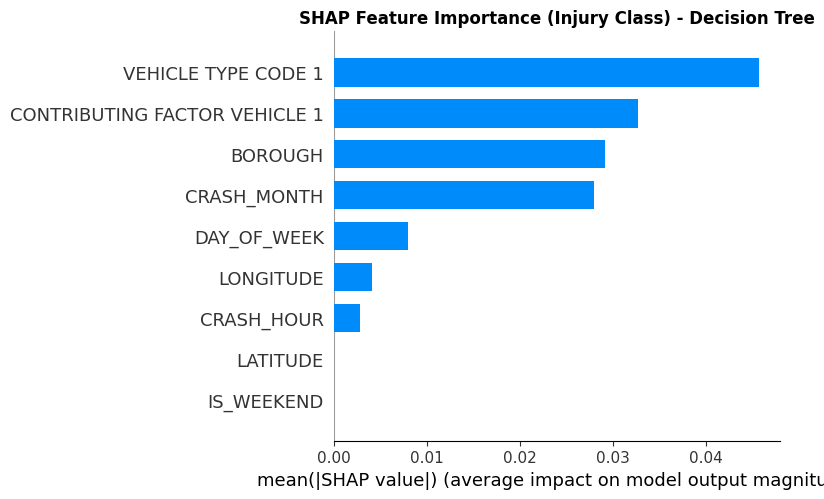

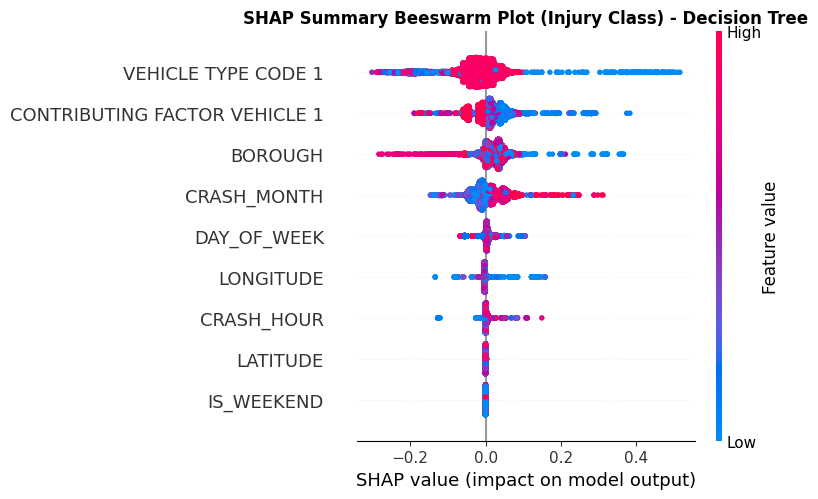

In [18]:
# Compute SHAP values using TreeExplainer
explainer = shap.TreeExplainer(dt_model)
shap_values = explainer.shap_values(X_test_scaled)

# Plot 1: SHAP Feature Importance Bar Chart
plt.figure(figsize=(10, 5))
plt.title('SHAP Feature Importance (Injury Class) - Decision Tree', fontsize=12, fontweight='bold')
shap.summary_plot(
    shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values[1], 
    X_test_scaled, 
    plot_type="bar", 
    show=False
)
plt.tight_layout()
plt.show()

# Plot 2: SHAP Beeswarm Summary Plot
plt.figure(figsize=(10, 5))
plt.title('SHAP Summary Beeswarm Plot (Injury Class) - Decision Tree', fontsize=12, fontweight='bold')
shap.summary_plot(
    shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values[1], 
    X_test_scaled, 
    show=False
)
plt.tight_layout()
plt.show()